# Setting up the Flatland Environment (Scenario 2: Granville - Harris Park, real timetable)

## 1. Installing relevant packages

In [1]:
pip install flatland-rl

Note: you may need to restart the kernel to use updated packages.


## 2. Defining key variables and functions

### 2.1 Defining the variables

Importing relevant packages

In [2]:
import json
from pathlib import Path

from flatland.envs.persistence import RailEnvPersister
from flatland.envs.rail_env_action import RailEnvActions
from flatland.envs.observations import GlobalObsForRailEnv
from flatland.envs.step_utils.states import TrainState
from flatland.core.effects_generator import EffectsGenerator, make_multi_effects_generator
from flatland.envs.malfunction_effects_generators import MalfunctionEffectsGenerator
from flatland.envs.malfunction_generators import MalfunctionParameters, ParamMalfunctionGen

from flatland.utils.rendertools import RenderTool
from IPython.display import display, clear_output
from PIL import Image
import PIL

from flatland.envs.agent_utils import EnvAgent
from flatland.envs.timetable_utils import Line
from flatland.envs.rail_trainrun_data_structures import Waypoint

from flatland.envs.timetable_utils import Timetable
from collections import Counter, deque
import statistics
import time

**Scenario 2 layout (`scenario2_env.mpk`, 20 x 20 grid)**

Harris Park is the west end of the corridor and Granville is the east end. As in Scenario 1, trains running EAST are "Up" trains, heading towards Sydney. The track order follows the Granville platforms: Up Main, Down Main, Up Suburban, Down Suburban.

| Row | Track | Normal direction |
|---|---|---|
| 5 | Up Main | East (Harris Park → Granville) |
| 7 | Down Main | West (Granville → Harris Park) |
| 9 | Up Suburban | East |
| 11 | Down Suburban | West |
| (14,16) → (9,14) | Up South West line from Merrylands | Merges into the Up Suburban at (9,14) |
| (11,16) → (13,18) | Down South West line to Merrylands | Leaves the Down Suburban at (11,16) |

| Feature | Cell(s) | Notes |
|---|---|---|
| SW merge | (9,14) | Up SW trains heading north join the Up Suburban heading east |
| SW junction (branch) | (11,16) | A westbound Down Suburban train takes `MOVE_LEFT` to go to Merrylands |
| Diamond crossing | (11,14) | The Up SW line crosses the Down Suburban (flat crossing: trains wait for each other) |
| Crossovers X1 to X5 | cols 4, 6, 7, 11, 13 | Single "/" links. Westbound trains move DOWN one track and eastbound trains move UP one track (`MOVE_LEFT` in both cases) |

Scenario 1 is a **parallel-track rerouting** problem. Scenario 2 is a **junction, merge and branch (conflict and convergence)** problem.

**Real timetable (`scenario2_timetable_20261015.json`, built by `build_scenario2_timetable.py`)**

The trains come from the TfNSW Greater Sydney GTFS timetable for Thursday 15 October 2026, 16:00-19:00 (the same window as Scenario 1). As in Scenario 1, only trains that stop at every modelled station they pass are kept, so express trains are dropped. This leaves 54 T2 trains; the 14 T5 trains use the Harris Park - Merrylands link, which is not on the map, and are dropped too.

| Segment | Trains | Map start → target |
|---|---|---|
| Harris Park → Granville | 12 | Up Suburban (9,1) → (9,18) |
| Merrylands → Granville | 12 | Up SW (14,16) → Up Suburban (9,18) |
| Granville → Harris Park | 12 | Down Suburban (11,18) → (11,1) |
| Granville → Merrylands | 18 | Down Suburban (11,18) → Down SW (13,18) |

One step is 20 seconds (as in Scenario 1), so step 0 is 16:00 and the window ends at step 540.

In [3]:
# --------------------------------------------------
# Defining directions
# --------------------------------------------------
NORTH = 0
EAST = 1    # Up direction   (towards Granville / Sydney)
SOUTH = 2
WEST = 3    # Down direction (towards Harris Park)

# --------------------------------------------------
# Defining the train stations
# --------------------------------------------------
# Harris Park = west end of the corridor, Granville = east end.
# Track order follows the Granville platforms:
# Up Main, Down Main, Up Suburban, Down Suburban

STATIONS = {
    "Harris Park": {
        "up_main": (5, 1),
        "down_main": (7, 1),
        "up_suburban": (9, 1),
        "down_suburban": (11, 1)
    },
    "Granville": {
        "up_main": (5, 18),
        "down_main": (7, 18),
        "up_suburban": (9, 18),
        "down_suburban": (11, 18)
    },
    # External South-West branch towards Merrylands
    # (not modelled as a full station, just the end of the branch)
    "Merrylands": {
        "up_sw": (14, 16),     # Up SW line   -> merges into the Up Suburban at (9, 14)
        "down_sw": (13, 18)    # Down SW line <- leaves the Down Suburban at (11, 16)
    }
}

# --------------------------------------------------
# Defining the junction and the crossovers
# --------------------------------------------------
JUNCTIONS = {
    "sw_merge": (9, 14),      # Up SW trains (heading north) join the Up Suburban heading east
    "sw_diverge": (11, 16),   # Down Suburban trains turn LEFT here to take the SW branch
    "sw_crossing": (11, 14)   # Up SW line crosses the Down Suburban (diamond crossing)
}

# Each crossover is a single "/" link between two neighbouring tracks:
# - a westbound train takes MOVE_LEFT at the "westbound" cell to move DOWN one track
# - an eastbound train takes MOVE_LEFT at the "eastbound" cell to move UP one track
CROSSOVERS = {
    "X1": {"tracks": "Up Main <-> Down Main",         "westbound": (5, 4),  "eastbound": (7, 4)},
    "X2": {"tracks": "Down Main <-> Up Suburban",     "westbound": (7, 6),  "eastbound": (9, 6)},
    "X3": {"tracks": "Up Suburban <-> Down Suburban", "westbound": (9, 7),  "eastbound": (11, 7)},
    "X4": {"tracks": "Up Suburban <-> Down Suburban", "westbound": (9, 11), "eastbound": (11, 11)},
    "X5": {"tracks": "Down Main <-> Up Suburban",     "westbound": (7, 13), "eastbound": (9, 13)}
}

# --------------------------------------------------
# Environment settings
# --------------------------------------------------
# The diamond at (11, 14) is exported as a flat crossing in the .mpk (team decision)
# True  -> flyover: the Up SW line and the Down Suburban never block each other
# False -> flat crossing: trains have to wait for each other at the diamond
LEVEL_FREE_CROSSING = False

# --------------------------------------------------
# Timetable settings (same time scale as Scenario 1)
# --------------------------------------------------
# Find the repository from either its root or this notebook directory.
REPO_ROOT = next(
    root for root in [Path.cwd(), *Path.cwd().parents]
    if (root / "data" / "levels" / "scenario2_env.mpk").is_file()
)
ENV_FILE = REPO_ROOT / "data" / "levels" / "scenario2_env.mpk"
TIMETABLE_FILE = REPO_ROOT / "data" / "schedules" / "scenario2_timetable_20261015.json"   # built by build_scenario2_timetable.py
STEP_SECONDS = 20       # 1 step = 20 seconds
WINDOW_START = "16:00"  # step 0
DEADLINE_SLACK = 1      # steps added to the reference arrival (as in Scenario 1)
EXTRA_STEPS = 200       # steps kept after the last deadline (as in Scenario 1)

# --------------------------------------------------
# Operating conditions (same as Scenario 1)
# --------------------------------------------------
# "normal" is deterministic, "delayed" injects Poisson malfunctions (the paper's 1/540 interval)
CONDITIONS = {
    "normal": None,
    "delayed": 1 / 540,
}
MALFUNCTION_DURATION = (20, 50)   # steps a broken-down train stays stopped
SEEDS = [0, 1, 2]

In [4]:
# --------------------------------------------------
# Defining the trains (or agents) from the real timetable
# --------------------------------------------------
# Each service enters the map at its origin station and leaves at its destination.
# "route" = switch cells where the train has to turn (default is MOVE_FORWARD)

SEGMENT_MAP = {
    # Up Suburban, Harris Park -> Granville
    ("Harris Park", "Granville"): {
        "start": STATIONS["Harris Park"]["up_suburban"],
        "target": STATIONS["Granville"]["up_suburban"],
        "direction": EAST
    },
    # Up SW -> merges into the Up Suburban at (9, 14)
    # (the branch stub points east, so the train starts facing
    #  WEST and follows the curve north towards the junction)
    ("Merrylands", "Granville"): {
        "start": STATIONS["Merrylands"]["up_sw"],
        "target": STATIONS["Granville"]["up_suburban"],
        "direction": WEST
    },
    # Down Suburban, Granville -> Harris Park
    ("Granville", "Harris Park"): {
        "start": STATIONS["Granville"]["down_suburban"],
        "target": STATIONS["Harris Park"]["down_suburban"],
        "direction": WEST
    },
    # Down Suburban -> Down SW
    ("Granville", "Merrylands"): {
        "start": STATIONS["Granville"]["down_suburban"],
        "target": STATIONS["Merrylands"]["down_sw"],
        "direction": WEST,
        "route": {
            JUNCTIONS["sw_diverge"]: RailEnvActions.MOVE_LEFT
        }
    }
}


def to_step(clock, start=WINDOW_START):
    """Clock time 'HH:MM:SS' -> step number after the start of the window."""
    h, m, s = (int(x) for x in clock.split(":"))
    start_h, start_m = (int(x) for x in start.split(":"))
    seconds = (h * 3600 + m * 60 + s) - (start_h * 3600 + start_m * 60)
    return round(seconds / STEP_SECONDS)


def load_timetable_config(path=TIMETABLE_FILE):
    """Turn the extracted GTFS services into the train config used by the functions below."""
    with open(path) as f:
        timetable = json.load(f)

    train_config = []
    for service in timetable["services"]:
        segment = SEGMENT_MAP[(service["origin"], service["destination"])]
        train_config.append({
            "line": service["line"],

            "start": segment["start"],
            "target": segment["target"],

            "direction": segment["direction"],
            "departure": to_step(service["departure"]),

            "stops": [],

            "route": segment.get("route", {}),

            # Real times, kept for the results table
            "real_departure": service["departure"][:5],
            "real_arrival": service["arrival"][:5]
        })

    return train_config


REALISTIC_TIMETABLE_CONFIG = load_timetable_config()

print("Trains loaded:", len(REALISTIC_TIMETABLE_CONFIG))
print(Counter(f"{t['real_departure'][:2]}:00 hour" for t in REALISTIC_TIMETABLE_CONFIG))

Trains loaded: 54
Counter({'18:00 hour': 20, '17:00 hour': 18, '16:00 hour': 16})


In [5]:
# --------------------------------------------------
# Defining the disruption
# --------------------------------------------------
# Random malfunctions of the "delayed" condition are added in load_environment().
# Fixed breakdowns can still be added here for demonstrations:
# "train"    = index of the train in REALISTIC_TIMETABLE_CONFIG
# "step"     = step (as printed by run_manual_test) at which it breaks down
# "duration" = number of steps it stays broken down

DISRUPTION_CONFIG = []

### 2.2 Defining the functions

In [6]:
class Scenario2Effects(EffectsGenerator):
    """
    Hooks into env.reset() and env.step() to:
    1. re-apply the level-free crossing. env.reset(regenerate_rail=False) rebuilds
       the resource map and drops the level-free cell loaded from the .mpk file
    2. trigger the scheduled disruptions (train breakdowns)
    """

    def __init__(self, level_free_positions=(), disruptions=None):
        super().__init__()
        self.level_free_positions = set(level_free_positions)
        self.disruptions = disruptions or []

    def on_episode_start(self, env, *args, **kwargs):
        env.resource_map.level_free_positions = set(self.level_free_positions)
        return env

    def on_episode_step_start(self, env, *args, **kwargs):
        # env._elapsed_steps has already been incremented here, so
        # "Step 0" in run_manual_test is env._elapsed_steps == 1
        step = env._elapsed_steps - 1

        for disruption in self.disruptions:
            agent = env.agents[disruption["train"]]

            if disruption["step"] == step and agent.state != TrainState.DONE:
                agent.malfunction_handler.malfunction_down_counter = disruption["duration"]

        return env

In [7]:
def load_environment(level_free_crossing=LEVEL_FREE_CROSSING, disruptions=None, malfunction_rate=None):

    if level_free_crossing:
        level_free_positions = [JUNCTIONS["sw_crossing"]]
    else:
        level_free_positions = []

    effects = Scenario2Effects(level_free_positions, disruptions)

    # "delayed" condition: Poisson malfunctions, the same generator as Scenario 1
    if malfunction_rate is not None:
        malfunctions = MalfunctionEffectsGenerator(
            ParamMalfunctionGen(
                MalfunctionParameters(
                    malfunction_rate=malfunction_rate,
                    min_duration=MALFUNCTION_DURATION[0],
                    max_duration=MALFUNCTION_DURATION[1]
                )
            )
        )
        effects = make_multi_effects_generator(effects, malfunctions)

    env, env_dict = RailEnvPersister.load_new(
        str(ENV_FILE),
        obs_builder=GlobalObsForRailEnv(),
        effects_generator=effects
    )

    # The .mpk loads seed_history as a tuple, so reset(random_seed=...) cannot
    # append to it. Use a list (same fix as the Scenario 1 loader)
    env.seed_history = list(env.seed_history) or [0]

    return env

In [8]:
def shortest_running_time(env, start, direction, target):
    """
    Minimum number of moves from start (facing direction) to target,
    found with a breadth-first search over the rail transitions.
    """
    moves = {
        NORTH: (-1, 0),
        EAST: (0, 1),
        SOUTH: (1, 0),
        WEST: (0, -1)
    }

    queue = deque([(start, direction, 0)])
    visited = {(start, direction)}

    while queue:
        position, heading, distance = queue.popleft()

        if position == target:
            return distance

        transitions = env.rail.get_transitions((position, heading))

        for new_heading in range(4):
            if transitions[new_heading]:
                d_row, d_col = moves[new_heading]
                new_position = (position[0] + d_row, position[1] + d_col)

                if (new_position, new_heading) not in visited:
                    visited.add((new_position, new_heading))
                    queue.append((new_position, new_heading, distance + 1))

    raise ValueError(f"Target {target} cannot be reached from {start} facing {direction}")

In [9]:
def create_agents(train_config):

    agent_waypoints = {}

    # Create waypoints for each train
    for handle, train in enumerate(train_config):

        agent_waypoints[handle] = [
            [
               Waypoint(
                    position=train["start"],
                    direction=train["direction"]
                )
            ],
            [
                Waypoint(
                    position=train["target"],
                    direction=None
                )
            ]
        ]

    # Give every train normal speed
    agent_speeds = [1.0] * len(train_config)

    # Create the line
    line = Line(
        agent_waypoints=agent_waypoints,
        agent_speeds=agent_speeds
    )

    # Create Flatland agents
    agents = EnvAgent.from_line(line)

    return agents

In [10]:
def create_timetable(train_config, env):

    earliest_departures = []
    latest_arrivals = []

    for train in train_config:

        # Arrival on a clear line: Flatland puts a train on the map at
        # max(departure, 1) and it arrives one step after entering its target.
        # This is replaced by the calibrated deadline in setup_environment().
        running_time = shortest_running_time(
            env, train["start"], train["direction"], train["target"]
        )
        running_time += len(train["stops"])

        earliest_departures.append(
            [train["departure"], None]
        )

        latest_arrivals.append(
            [None, max(train["departure"], 1) + running_time + 1]
        )

    max_episode_steps = max(arrival for _, arrival in latest_arrivals) + EXTRA_STEPS

    timetable = Timetable(
        earliest_departures=earliest_departures,
        latest_arrivals=latest_arrivals,
        max_episode_steps=max_episode_steps
    )

    return timetable

In [11]:
def render_env(env, wait=True, env_renderer=None):
    if env_renderer is None:
        env_renderer = RenderTool(env)

    env_renderer.render_env()
    image = env_renderer.get_image()
    pil_image = PIL.Image.fromarray(image)

    clear_output(wait=wait)
    display(pil_image)

In [12]:
_REFERENCE_ARRIVALS = {}


def reference_arrivals(train_config):
    """
    Arrival step of every train when all trains follow their scripted route
    under normal conditions (no disruptions). Used to set reachable deadlines,
    the same way Scenario 1 calibrates its timetable.
    """
    key = id(train_config)

    if key not in _REFERENCE_ARRIVALS:
        env, agents = setup_environment(train_config, condition="normal", calibrate=False, verbose=False)
        env.reset(regenerate_rail=False, regenerate_schedule=False)
        run_manual_test(env, agents, train_config, render=False, verbose=False)
        _REFERENCE_ARRIVALS[key] = {agent.handle: agent.arrival_time for agent in env.agents}

    return _REFERENCE_ARRIVALS[key]


def setup_environment(train_config, level_free_crossing=LEVEL_FREE_CROSSING,
                      disruptions=None, condition="normal", calibrate=True, verbose=True):

    # Load environment
    env = load_environment(level_free_crossing, disruptions, CONDITIONS[condition])

    # Create the agents
    agents = create_agents(train_config)

    # Create the timetable
    timetable = create_timetable(train_config, env)

    # Apply the timetable
    agents = EnvAgent.apply_timetable(agents, timetable)

    # Calibrate the deadlines: reference arrival under normal conditions + slack
    if calibrate:
        arrivals = reference_arrivals(train_config)
        for agent in agents:
            measured = arrivals.get(agent.handle)
            if measured is not None:
                deadline = max(agent.latest_arrival, measured) + DEADLINE_SLACK
                agent.waypoints_latest_arrival = [None, deadline]
                agent.latest_arrival = deadline

    # Add fully configured agents to environment
    for agent in agents:
        env.add_agent(agent)

    # The .mpk keeps its own max_episode_steps (500), so apply our own value
    env._max_episode_steps = max(agent.latest_arrival for agent in agents) + EXTRA_STEPS

    # Initialise done status
    env.dones = {
        agent.handle: False
        for agent in agents
    }

    env.dones["__all__"] = False

    if not verbose:
        return env, agents

    # Print information
    departures = [train["real_departure"] for train in train_config]
    print("Number of agents:", len(env.agents))
    print("Lines:", dict(Counter(train["line"] for train in train_config)))
    print("Departures:", min(departures), "to", max(departures))
    print("Condition:", condition, "| Level-free crossing:", level_free_crossing)
    print("Fixed disruptions:", disruptions)
    print("Max episode steps:", env._max_episode_steps)

    return env, agents

In [13]:
def run_manual_test(env, agents, train_config, max_steps=None,
                    render=True, delay=2, verbose=True):

    if max_steps is None:
        max_steps = env._max_episode_steps

    # Define the renderer
    env_renderer = RenderTool(env) if render else None

    # Keep track of stations each agent has already stopped at
    completed_stops = {}
    for agent in agents:
        completed_stops[agent.handle] = set()

    for step in range(max_steps):

        actions = {}

        # ---------------------------------------------
        # Determine action for each agent
        # ---------------------------------------------
        for agent in agents:

            handle = agent.handle
            train = train_config[handle]

            # Default action = move forward
            actions[handle] = RailEnvActions.MOVE_FORWARD

            # Agent may be off the map because it has
            # not departed yet or has already finished
            if agent.current_configuration is None:
                continue

            # Get current position
            current_position = agent.current_configuration[0]

            # -----------------------------------------
            # Check if this is a scheduled station stop
            # -----------------------------------------
            if (
                current_position in train["stops"]
                and current_position not in completed_stops[handle]
            ):

                # Stop train for this timestep
                actions[handle] = RailEnvActions.STOP_MOVING

                # Remember that this stop has been completed
                completed_stops[handle].add(current_position)

                if verbose:
                    print(
                        f"Agent {handle} stopping at "
                        f"{current_position}"
                    )

            # -----------------------------------------
            # Check if the train has to turn here
            # (junction / crossover on its route)
            # -----------------------------------------
            elif current_position in train.get("route", {}):

                actions[handle] = train["route"][current_position]

                if verbose:
                    print(
                        f">>> Agent {handle} taking "
                        f"{actions[handle].name} at {current_position}"
                    )

        # ---------------------------------------------
        # Take next action
        # ---------------------------------------------
        observations, rewards, dones, info = env.step(actions)

        # ---------------------------------------------
        # Render environment
        # ---------------------------------------------
        if render:
            render_env(env, env_renderer=env_renderer)

            # Pause so movement is visible
            time.sleep(delay)

            # ---------------------------------------------
            # Print agent information
            # ---------------------------------------------
            print(f"\nStep {step}")

            for agent in env.agents:
                malfunction = agent.malfunction_handler.malfunction_down_counter
                print(
                    f"Agent {agent.handle}:",
                    agent.current_configuration,
                    "state:",
                    agent.state.name,
                    f"(broken down for {malfunction} more steps)" if malfunction > 0 else ""
                )

        # ---------------------------------------------
        # End episode when all agents are finished
        # ---------------------------------------------
        if dones["__all__"]:
            if verbose:
                print("All agents finished!")
            break

In [14]:
def print_results(env, train_config, show_trains=True):
    """
    Delay = steps late compared with the timetable (latest arrival)
    Lost  = steps lost to conflicts / disruptions compared with a clear run
    """

    if show_trains:
        print(f"{'Agent':<7}{'Line':<6}{'Real dep':>9}{'Departure':>10}{'Arrival':>9}{'Latest':>8}{'Delay':>7}{'Lost':>6}   State")

    total_delay = 0
    total_lost = 0
    arrived = 0
    on_time = 0

    for agent in env.agents:
        train = train_config[agent.handle]

        # Arrival on a clear line: Flatland puts a train on the map at
        # max(departure, 1) and it arrives one step after entering its target
        running_time = shortest_running_time(
            env, train["start"], train["direction"], train["target"]
        )
        running_time += len(train["stops"])
        clear_run_arrival = max(train["departure"], 1) + running_time + 1

        if agent.arrival_time is None:
            arrival = "-"
            delay = "-"
            lost = "-"
        else:
            arrived += 1
            arrival = agent.arrival_time
            delay = max(0, agent.arrival_time - agent.latest_arrival)
            lost = agent.arrival_time - clear_run_arrival
            total_delay += delay
            total_lost += lost
            on_time += delay == 0

        if show_trains:
            print(
                f"{agent.handle:<7}{train['line']:<6}{train['real_departure']:>9}{agent.earliest_departure:>10}"
                f"{arrival:>9}{agent.latest_arrival:>8}{delay:>7}{lost:>6}   {agent.state.name}"
            )

    n = len(env.agents)
    print()
    print(f"Trains arrived: {arrived}/{n}")
    print(f"On time: {on_time}/{n}")
    print(f"Total delay: {total_delay} steps ({total_delay * STEP_SECONDS / 60:.1f} min)")
    print(f"Mean delay per arrived train: {total_delay / max(arrived, 1):.2f} steps")
    print(f"Total time lost to conflicts / disruptions: {total_lost} steps ({total_lost * STEP_SECONDS / 60:.1f} min)")

    return {"arrived": arrived, "on_time": on_time, "total_delay": total_delay, "total_lost": total_lost}

## 3. Implementing the real timetable (normal condition)

Every train follows its scripted route (it only turns where its route requires). Under the normal condition this is also the reference run used to set the deadlines, so every train should arrive on time.

In [15]:
# Setting up the environment with the real timetable
env, agents = setup_environment(REALISTIC_TIMETABLE_CONFIG, condition="normal")

# Reset/ initialise the environment
observations, info = env.reset(
    regenerate_rail=False, # Keeps the railway exactly as designed.
    regenerate_schedule=False # Keeps the agent schedule you created instead of generating a new one.
)

# 54 trains over ~750 steps: run without rendering every step
run_manual_test(env, agents, REALISTIC_TIMETABLE_CONFIG, render=False, verbose=False)

Number of agents: 54
Lines: {'T2': 54}
Departures: 16:00 to 18:59
Condition: normal | Level-free crossing: False
Fixed disruptions: None
Max episode steps: 745


In [16]:
normal_results = print_results(env, REALISTIC_TIMETABLE_CONFIG)

Agent  Line   Real dep Departure  Arrival  Latest  Delay  Lost   State
0      T2        16:00         2       20      21      0     0   DONE
1      T2        16:01         4       22      23      0     0   DONE
2      T2        16:04        12       19      20      0     0   DONE
3      T2        16:11        35       47      48      0     0   DONE
4      T2        16:15        47       65      66      0     0   DONE
5      T2        16:16        49       67      68      0     0   DONE
6      T2        16:19        57       64      65      0     0   DONE
7      T2        16:26        80       92      93      0     0   DONE
8      T2        16:30        92      110     111      0     0   DONE
9      T2        16:31        94      112     113      0     0   DONE
10     T2        16:34       102      109     110      0     0   DONE
11     T2        16:41       125      137     138      0     0   DONE
12     T2        16:45       137      155     156      0     0   DONE
13     T2        16

### 3.1 How busy is the map?

Count the trains on the map at every step while all trains follow their scripted routes.

In [17]:
def trains_on_map(condition="normal", seed=None):
    """Number of trains on the map (and broken down) at every step of one scripted episode."""
    env, agents = setup_environment(REALISTIC_TIMETABLE_CONFIG, condition=condition, verbose=False)
    env.reset(regenerate_rail=False, regenerate_schedule=False, random_seed=seed)

    counts = []
    for step in range(env._max_episode_steps):
        actions = {}
        for agent in env.agents:
            route = REALISTIC_TIMETABLE_CONFIG[agent.handle].get("route", {})
            position = agent.current_configuration[0] if agent.current_configuration else None
            actions[agent.handle] = route.get(position, RailEnvActions.MOVE_FORWARD)

        observations, rewards, dones, info = env.step(actions)

        on_map = [agent for agent in env.agents if agent.current_configuration is not None]
        broken = [agent for agent in on_map if agent.malfunction_handler.malfunction_down_counter > 0]
        counts.append((env._elapsed_steps, len(on_map), len(broken)))

        if dones["__all__"]:
            break

    return counts


counts = trains_on_map("normal")
on_map = [n for _, n, _ in counts]
print(f"Trains on the map (normal): max {max(on_map)}, mean {statistics.mean(on_map):.2f}")
print(f"Steps with 2 or more trains: {sum(n >= 2 for n in on_map)} of {len(on_map)}")
print(f"Steps with 3 or more trains: {sum(n >= 3 for n in on_map)} of {len(on_map)}")

Trains on the map (normal): max 3, mean 1.19
Steps with 2 or more trains: 209 of 544
Steps with 3 or more trains: 24 of 544


## 4. Delayed condition (random malfunctions)

The research question for Scenario 2 is whether the agent can manage trains converging around a disruption. Under the delayed condition, trains break down at random (Poisson, rate 1/540, 20-50 steps), as in Scenario 1. The Up Suburban trains from Harris Park and the SW trains from Merrylands all converge on the merge at (9,14), so a breakdown near the junction delays both streams. The scripted routes below are the baseline the RL agents have to beat.

In [18]:
delayed_results = {}

for seed in SEEDS:
    env, agents = setup_environment(REALISTIC_TIMETABLE_CONFIG, condition="delayed", verbose=(seed == SEEDS[0]))

    observations, info = env.reset(
        regenerate_rail=False,
        regenerate_schedule=False,
        random_seed=seed
    )

    run_manual_test(env, agents, REALISTIC_TIMETABLE_CONFIG, render=False, verbose=False)

    print(f"\n--- seed {seed} ---")
    delayed_results[seed] = print_results(env, REALISTIC_TIMETABLE_CONFIG, show_trains=False)

Number of agents: 54
Lines: {'T2': 54}
Departures: 16:00 to 18:59
Condition: delayed | Level-free crossing: False
Fixed disruptions: None
Max episode steps: 745



--- seed 0 ---

Trains arrived: 54/54
On time: 49/54
Total delay: 170 steps (56.7 min)
Mean delay per arrived train: 3.15 steps
Total time lost to conflicts / disruptions: 175 steps (58.3 min)



--- seed 1 ---

Trains arrived: 54/54
On time: 46/54
Total delay: 201 steps (67.0 min)
Mean delay per arrived train: 3.72 steps
Total time lost to conflicts / disruptions: 212 steps (70.7 min)



--- seed 2 ---

Trains arrived: 54/54
On time: 53/54
Total delay: 40 steps (13.3 min)
Mean delay per arrived train: 0.74 steps
Total time lost to conflicts / disruptions: 41 steps (13.7 min)


In [19]:
# Mean and standard deviation over the seeds
print(f"{'Metric':<18}{'Normal':>10}{'Delayed (mean ± std)':>26}")
for metric in ["arrived", "on_time", "total_delay", "total_lost"]:
    values = [result[metric] for result in delayed_results.values()]
    print(f"{metric:<18}{normal_results[metric]:>10}{statistics.mean(values):>16.1f} ± {statistics.stdev(values):.1f}")

Metric                Normal      Delayed (mean ± std)
arrived                   54            54.0 ± 0.0
on_time                   54            49.3 ± 3.5
total_delay                0           137.0 ± 85.4
total_lost                 0           142.7 ± 90.0


### 4.1 Snapshot of a breakdown

The image shows the network at 17:44:20 (step 313) under the delayed condition with seed 1: four trains are on the map and one of them is broken down.

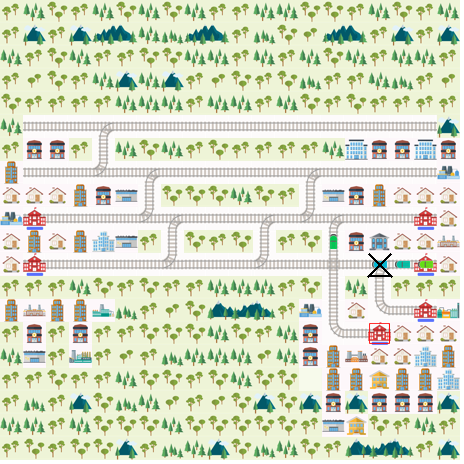

Step 313 (17:44:20): 4 trains on the map, 1 broken down


In [20]:
env, agents = setup_environment(REALISTIC_TIMETABLE_CONFIG, condition="delayed", verbose=False)
env.reset(regenerate_rail=False, regenerate_schedule=False, random_seed=SEEDS[1])

# Run the scripted routes up to 17:44:20, then render once
run_manual_test(env, agents, REALISTIC_TIMETABLE_CONFIG, max_steps=to_step("17:44:20"), render=False, verbose=False)
on_map = sum(agent.current_configuration is not None for agent in env.agents)
broken = sum(agent.current_configuration is not None and agent.malfunction_handler.malfunction_down_counter > 0
             for agent in env.agents)
render_env(env)
print(f"Step {env._elapsed_steps} (17:44:20): {on_map} trains on the map, {broken} broken down")